# CODE PART 2 of 2 - Shark Movement Forecasting: An Assessment for Ocean Recreational Safety

---
By: Isabella Parlato
Github Repository: https://github.com/ParlatoI/Shark-Forecasting_Capstone

In [1]:
# inital loading of libraries

import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# for preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit

# for unsupervised methods
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


# for supervised methods
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from statsmodels.stats.stattools import durbin_watson
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier


In [2]:
# function for determining ideal split-ratio for train-test sets

import sys

## Check if packages are loaded; if not, import them
if 'numpy' not in sys.modules:
    import numpy as np
if 'pandas' not in sys.modules:
    import pandas as pd


def calcSplitRatio(df, p=None):
    """
    Calculate the ideal split ratio for training and testing sets.

    Parameters:
    p (int): The number of parameters (optional). If not provided, defaults to
    the number of columns minus 1 (assuming the last column is the target).

    df (DataFrame): The DataFrame that will be used for analysis.

    Returns:
    float: The training set proportion.
    """
    ## Set p to the number of predictors if not provided
    if p is None:
        p = df.shape[1] - 1  ## The number of features (predictors),
                             ## assuming last column is target

    ## Calculate ideal number for testing set
    test_N = (1 / np.sqrt(p)) * len(df)

    ## Calculate testing proportion
    test_prop = round(test_N / len(df), 2)

    ## Calculate training proportion
    train_prop = 1 - test_prop

    ## Print the results
    print(f"The ideal split ratio is {train_prop}:{test_prop} training:testing")

    ## Return the size of the training set proportion
    return train_prop


# Pull in dataset - further tidying & eda for final cleaned dataset

In [3]:
# load cleaned dataset

cleaned_url = (
    "https://raw.githubusercontent.com/ParlatoI/"
    "Shark-Forecasting_Capstone/main/cleaned_datasets/"
    "cleaned_merged_shark_buoy.csv"
)

full_df = pd.read_csv(cleaned_url)

print("Final modeling dataset shape:", full_df.shape)
full_df.head()

Final modeling dataset shape: (257940, 14)


,lon,lat,timestamp,hour,minute,wdir,wspd,pres,atmp,datetime,presence,year,month,day
0,-80.185,28.508,2010-01-01 19:20:00,19.0,20.0,328.0,10.1,1013.1,17.1,2010-01-01 19:20:00,0,2010.0,1.0,1.0
1,-80.185,28.508,2010-01-01 19:50:00,19.0,50.0,320.0,12.1,1013.0,16.8,2010-01-01 19:50:00,0,2010.0,1.0,1.0
2,-80.185,28.508,2010-01-01 20:20:00,20.0,20.0,336.0,10.4,1012.9,16.7,2010-01-01 20:20:00,0,2010.0,1.0,1.0
3,-80.185,28.508,2010-01-01 20:50:00,20.0,50.0,318.0,13.3,1013.9,17.3,2010-01-01 20:50:00,0,2010.0,1.0,1.0
4,-80.185,28.508,2010-01-01 21:20:00,21.0,20.0,323.0,12.9,1014.7,16.3,2010-01-01 21:20:00,0,2010.0,1.0,1.0


In [4]:
# sort by time
df = full_df.sort_values("timestamp").copy()

# extract presence rows
presence_df = df[df["presence"] == 1].copy()

# absences restricted to same active window
start_date = presence_df["timestamp"].min()
end_date   = presence_df["timestamp"].max()

window_absences = df[
    (df["timestamp"] >= start_date) &
    (df["timestamp"] <= end_date) &
    (df["presence"] == 0)
].copy()

# downsample absences to 3:1 ratio
absence_sample = window_absences.sample(
    n=min(len(window_absences), 3 * len(presence_df)),
    random_state=42
)

# combine
model_df = pd.concat([presence_df, absence_sample], ignore_index=True)
model_df = model_df.sort_values("timestamp").reset_index(drop=True)

print(model_df["presence"].value_counts(normalize=True))


presence
0    0.75
1    0.25
Name: proportion, dtype: float64


The above code block pulls in the cleaned combined dataset with both the shark tracking and buoy data. It aims to keep only the timestamps where sharks were actually detected and restricts absences data to same date ranges to avoid leakage from periods of no shark detections. There's a significant class imbalance between shark presence and absence so a 3:1 absence:presence downsampling ratio was used to add a bit more balance to avoid model bias towards predicting absence.

In [5]:
# EXPORT FINAL CLEANED DATASET VERSION

model_df.to_csv("final_model_dataset_shark_presence.csv", index=False)

In [6]:
# model_df dictionary

def create_data_dictionary(df):
    """
    Generate a data dictionary including column name,
    data type, percent missing, and example values.
    """

    data_dict = pd.DataFrame({
        "column_name": df.columns,
        "data_type": df.dtypes.astype(str),
        "percent_missing": df.isna().mean().round(4),
        "example_value": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().size > 0 else None)
    })

    return data_dict


# Generate dictionary
data_dictionary = create_data_dictionary(model_df)

# Display it
data_dictionary

,column_name,data_type,percent_missing,example_value
lon,lon,float64,0.0000,-80.098636
lat,lat,float64,0.0000,25.472697
timestamp,timestamp,object,0.0000,2010-11-13 12:00:00
hour,hour,float64,0.0000,11.0
minute,minute,float64,0.0000,50.0
wdir,wdir,float64,0.0032,20.0
wspd,wspd,float64,0.0004,5.8
pres,pres,float64,0.0160,1020.4
atmp,atmp,float64,0.0069,22.8
datetime,datetime,object,0.0000,2010-11-13 11:50:00


In [7]:
# class balance table

class_balance = (
    model_df["presence"]
    .value_counts()
    .rename_axis("presence")
    .reset_index(name="count")
)

class_balance["percent"] = class_balance["count"] / class_balance["count"].sum() * 100
class_balance


,presence,count,percent
0,0,15546,75.0
1,1,5182,25.0


retained class imbalance even after temporal restriction and controlled downsampling (approx. 3:1 ration of abs. to pres.); dataset remains moderately imbalanced so motivates use of eval. metrics beyond accuracy, including ROC-AUC & precision-recall curves

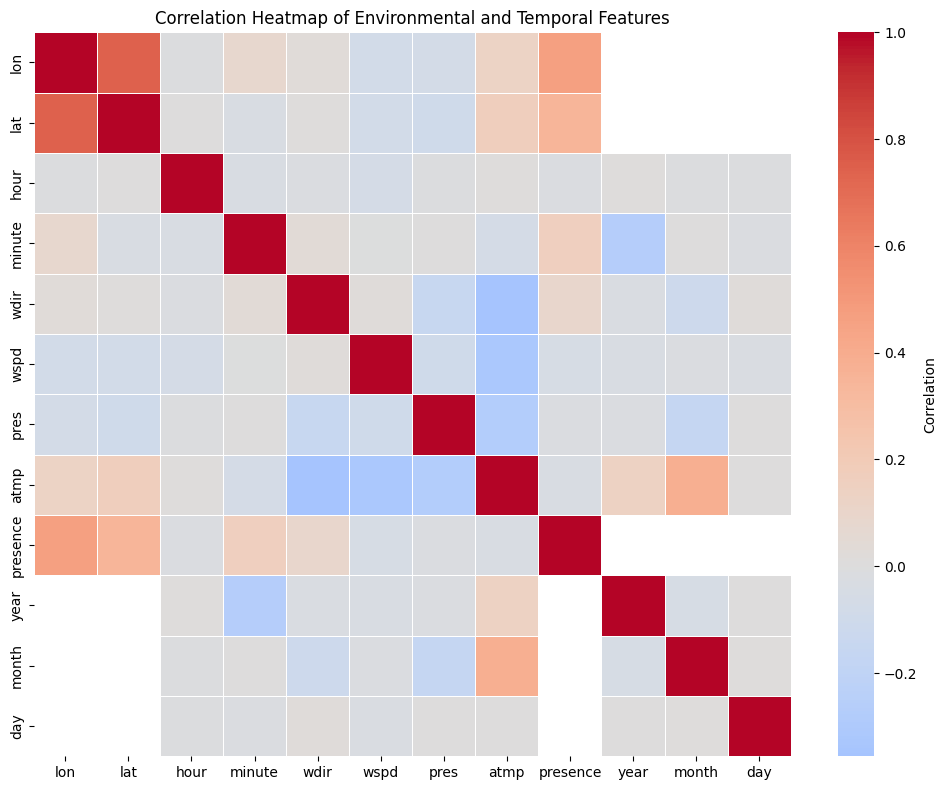

In [8]:
# Correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features only
numeric_cols = model_df.select_dtypes(include=["float64", "int64"])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap of Environmental and Temporal Features")
plt.tight_layout()
plt.show()


longitude and latitude have strongest pos. correlation with shark pres.; envir. var. show weak but interpretable relationships. atmp has mild pos. corr. with pres. - sharks more likely during warmer conditions/seasonal migration patterns; wspd & wdir very weak corr.; sea level pressure (pres) has near-zero corr. with pres. so indicates not reliable predicator alone.

weak corr. don't mean var. irrelevant, only effects may likely be nonlinear, conditional or seasonal

low multicollinearity (besides lon & lat and monthh & atmp)

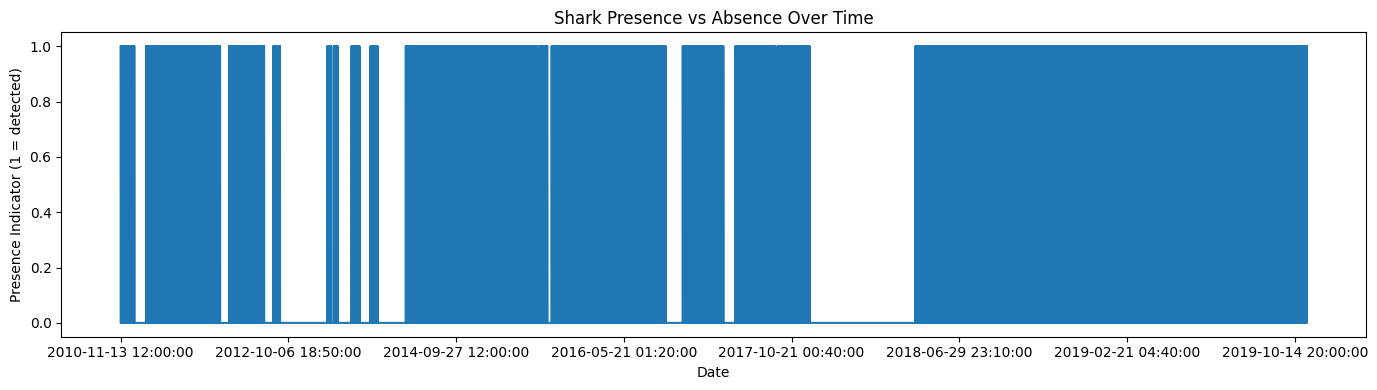

In [9]:
# presence vs absence over time plot

plt.figure(figsize=(14,4))
model_df.groupby("timestamp")["presence"].mean().plot()
plt.title("Shark Presence vs Absence Over Time")
plt.xlabel("Date")
plt.ylabel("Presence Indicator (1 = detected)")
plt.tight_layout()
plt.show()

There's definitely periods of time where the shark detections were clustered together so need to keep that in mind when doing time-aware splitting of data whereas it pertains to maintaining class balance for target variable while avoiding leakage.

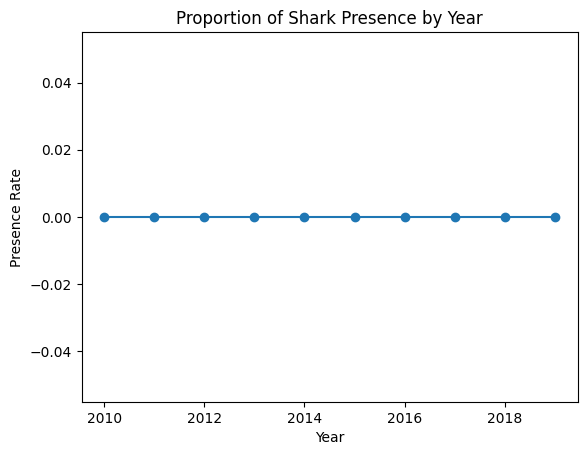

In [10]:
# time distribution of shark pres.

model_df.groupby("year")["presence"].mean().plot(kind="line", marker="o")
plt.title("Proportion of Shark Presence by Year")
plt.ylabel("Presence Rate")
plt.xlabel("Year")
plt.show()


line is flat & extremely close to zero; shark detections are rare relative to total obs.; no obvious long-term increasing or decreasing trend is visable

Doesn't mean sharks are absent but: obs. very frequent, detections sparse, pres. episodic instead of con't

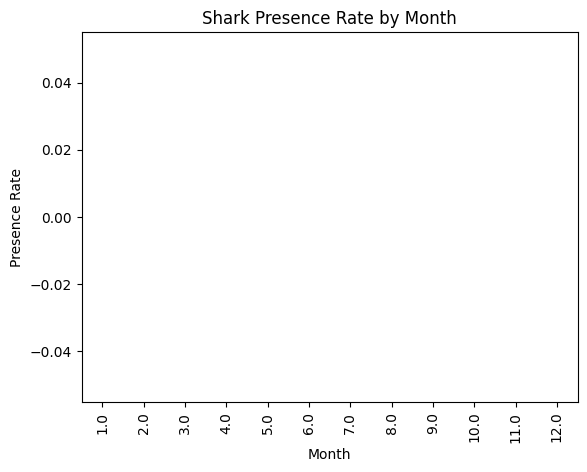

In [11]:
# seasonal presence distribution

model_df.groupby("month")["presence"].mean().plot(kind="bar")
plt.title("Shark Presence Rate by Month")
plt.ylabel("Presence Rate")
plt.xlabel("Month")
plt.show()


pres. is sparse, monthly aggregation smooths away rare events, downsampling & time restriction further reduces visible signal

monthly seasonality exists biologically but not well captured by simple proportions. didn't reveal strong seasonal signals in raw pres. rates, suggesting shark pres. influenced by finer-scale envir. conditions rather than cal. month alone - *at least based on the data that we have available to work with

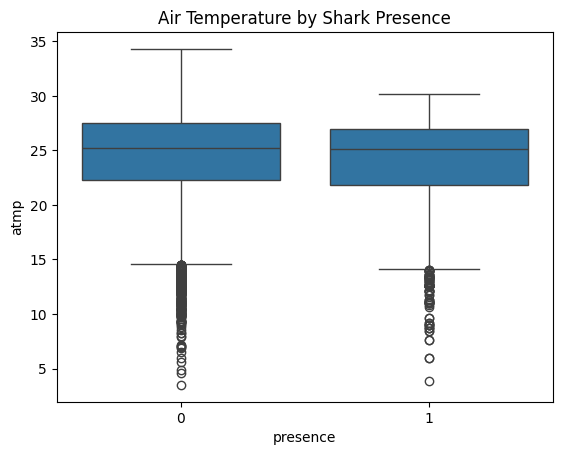

In [12]:
# environmental differences btwn pres. vs abs. - atmp

import seaborn as sns

sns.boxplot(data=model_df, x="presence", y="atmp")
plt.title("Air Temperature by Shark Presence")
plt.show()


warmer air temps are assoc. with pres though because of substantial overlap of pres. & abs. conditions, supports multivariate modeling approach. indicates temp alone insufficient for reliable prediction

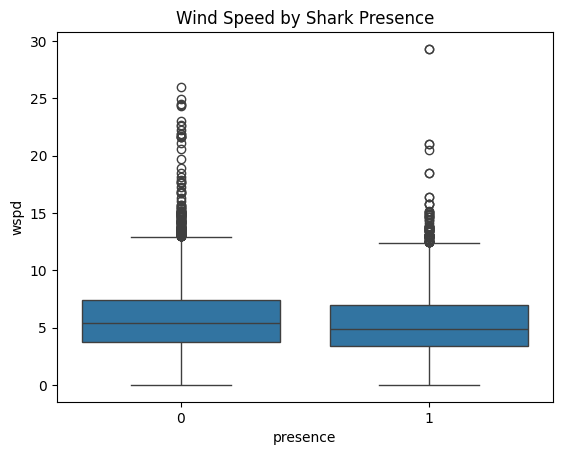

In [13]:
# environmental differences btwn pres. vs abs. - wspd

import seaborn as sns

sns.boxplot(data=model_df, x="presence", y="wspd")
plt.title("Wind Speed by Shark Presence")
plt.show()


similar medians, slightly narrower distribution during pres.

exteme wind conditions may reduce detectability and/or shark activity; wind speed likely contextual var., not a driving var.

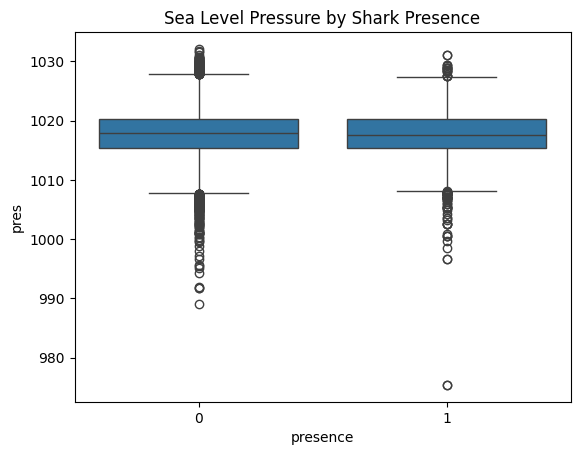

In [14]:
# environmental differences btwn pres. vs abs. - pres

import seaborn as sns

sns.boxplot(data=model_df, x="presence", y="pres")
plt.title("Sea Level Pressure by Shark Presence")
plt.show()

pres. clusters tightly around typical high pressure conditions with fewer extreme low-pres values during pres.

shark pres. may be less likely during storm systems - most detections observed under stable conditions

# Split into train & test sets - model specific preprocessing

In [15]:
# use ideal split ratio function

# calc. recommended split ratio
recommended_train_ratio = calcSplitRatio(full_df)

# convert to split index
split_idx = int(len(full_df) * recommended_train_ratio)


The ideal split ratio is 0.72:0.28 training:testing


In [16]:
# Stratified Split for Supervised Models dataset
## should keep class bal. while preserving chron. ordering

from sklearn.model_selection import StratifiedShuffleSplit

df_sup = model_df.copy()
y = df_sup["presence"]

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.28, random_state=42)

for train_idx, test_idx in sss.split(df_sup, y):
    train_df_sup = df_sup.iloc[train_idx].sort_values("timestamp").copy()
    test_df_sup  = df_sup.iloc[test_idx].sort_values("timestamp").copy()

print("Train balance:")
print(train_df_sup["presence"].value_counts(normalize=True))

print("\nTest balance:")
print(test_df_sup["presence"].value_counts(normalize=True))


Train balance:
presence
0    0.75
1    0.25
Name: proportion, dtype: float64

Test balance:
presence
0    0.75
1    0.25
Name: proportion, dtype: float64


Time-aware splitting/lagging kept resulting in the presence of only one class in test and/or train sets when trying different versions of integrating it. The stratified split addresses the extreme class imbalance by keeping the set percentages of each class. After splitting the data, the chronological order is maintained to avoid data leakage by sorting each data split by time after. This method is only used on the Supervised Model dataset since it's primary focus is related to the target variable (shark presence vs absence) that we're trying to predict. Unsupervised models don't use target variables as their focus is typically on looking for patterns in the features and most unsupervised models don't care about the concept of class balance as they are not learning from the target variable.

In [17]:
# supervised preprocessing pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Remove timestamp/date columns
train_df_mod = train_df_sup.drop(columns=["timestamp", "datetime"], errors="ignore").copy()
test_df_mod  = test_df_sup.drop(columns=["timestamp", "datetime"], errors="ignore").copy()

# Separate predictors/target
X_train = train_df_mod.drop(columns=["presence"])
y_train = train_df_mod["presence"]

X_test = test_df_mod.drop(columns=["presence"])
y_test = test_df_mod["presence"]

# Identify numeric + categorical
numeric_features = X_train.select_dtypes(include=["float64", "int64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler())
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

supervised_preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)

# Apply preprocessing
X_train_processed = supervised_preprocessor.fit_transform(X_train)
X_test_processed  = supervised_preprocessor.transform(X_test)

print("Processed shapes:", X_train_processed.shape, X_test_processed.shape)



Processed shapes: (14924, 11) (5804, 11)


Supervised models need standardized numeric inputs to keep equal contribution and encoded (one-hot) categorical inputs.

In [18]:
# unsupervised preprocessing pipeline

# Create clean copies for unsupervised modeling
train_df_unsup = train_df_sup.copy()
test_df_unsup  = test_df_sup.copy()

# Remove non-numeric fields for clustering
unsup_train = train_df_unsup.drop(columns=["presence", "timestamp", "datetime"], errors="ignore")
unsup_train = unsup_train.select_dtypes(include=["float64", "int64"])

unsup_test  = test_df_unsup.drop(columns=["presence", "timestamp", "datetime"], errors="ignore")
unsup_test  = unsup_test[unsup_train.columns]  # ensure matching columns

# Impute + scale
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()

unsup_train_imp = imputer.fit_transform(unsup_train)
unsup_test_imp  = imputer.transform(unsup_test)

X_unsup_train = scaler.fit_transform(unsup_train_imp)
X_unsup_test  = scaler.transform(unsup_test_imp)

print("Unsupervised matrix shape:", X_unsup_train.shape)
print("Any NaNs:", np.isnan(X_unsup_train).any())


Unsupervised matrix shape: (14924, 11)
Any NaNs: False


Unsupervised models must operate on purely numeric variables because clustering can only look at numbers so only keeping so non-numeric fields removed.

# Unsupervised Models

In [19]:
# K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_unsup_train)

train_df_unsup.loc[:, "kmeans_cluster"] = kmeans.labels_
test_df_unsup.loc[:, "kmeans_cluster"] = kmeans.predict(X_unsup_test)
## .loc to clear up pd warnings

print("K-means cluster counts:", pd.Series(kmeans.labels_).value_counts())


K-means cluster counts: 2    9605
0    4514
1     805
Name: count, dtype: int64


Cluster 2 was by far the largest group so it likely represents typical ocean and weather conditions. Cluster 0 is the mid-sized cluster of the three and is about half the size of Cluster 2 so these conditions happen often but not nearly as much as the largest cluster so they may be linked to common seasonal changes or more typical mild weather variations. Finally, Cluster 1, which is by far the smallest represents times when there were more extreme and fairly distinct environmental factors like those caused by storms for example.

In [20]:
# K-Means Clustering - how do these clusters relate to shark presence?

# merge presence back into unsupervised df for interpretation only
interpret_df = train_df_unsup.copy()
interpret_df["presence"] = train_df_sup["presence"].values

pd.crosstab(
    interpret_df["kmeans_cluster"],
    interpret_df["presence"],
    normalize="index"
)


presence,0,1
kmeans_cluster,,
0,0.767390,0.232610
1,0.000000,1.000000
2,0.804685,0.195315


Cluster 1 seemingly had 100% shark presence while Clusters 0 and 2 show primarily shark absence. It definitely raises a flag but the K-Means model definitely didn't use the presence label when generating the initial clusters so this Cluster 1 result seemingly doesn't appear to be caused by leakage. Further exploration is needed to determine if this is meaningful separation and not related to coding or data errors factoring in.

In [21]:
# K-Means Clustering: cluster centroids
## looking for what makes Cluster 1 different

centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=unsup_train.columns)
centroids_df


,lon,lat,hour,minute,wdir,wspd,pres,atmp,year,month,day
0,-0.199749,-0.265737,-0.026549,0.078433,0.427122,0.359003,0.529396,-1.141455,-8.716060e-02,-8.633933e-01,-7.335075e-02
1,3.429772,3.591066,-0.003228,-0.162685,0.121339,-0.376297,-0.345923,0.663588,5.817849e-30,-6.144964e-16,2.314734e-16
2,-0.194333,-0.176895,0.012739,-0.023165,-0.210771,-0.136976,-0.219545,0.480282,4.093082e-02,4.054515e-01,3.444568e-02


each row represents avg. standardized profile of said clusterd and since features were standardized, above-average conditions are positive values while below average conditions are reflected in negative values. Cluster 1 (shark-filled cluster): elevated lat & long values so distinct spatial area/region, higher air temp to other clusters, and lower wind speed & pres. so seem like calmer conditions. Clusters 0 & 2 had more moderate variables and seem to relate to typical background ocean conditions. These results help with showing that shark detections are more likely given specific spatial and environmental factors.

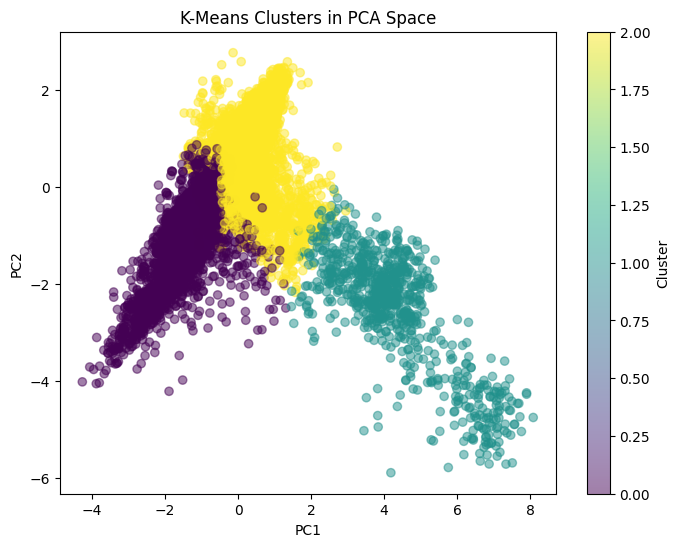

In [22]:
# K-Means Clustering: PCA visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup_train)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans.labels_, cmap='viridis', alpha=0.5)
plt.title("K-Means Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()


clusers seem very distinct and well separated along PC1 & PC2 so this indicates that K-Means identified meaningful structure for k=3 exploratory analysis.

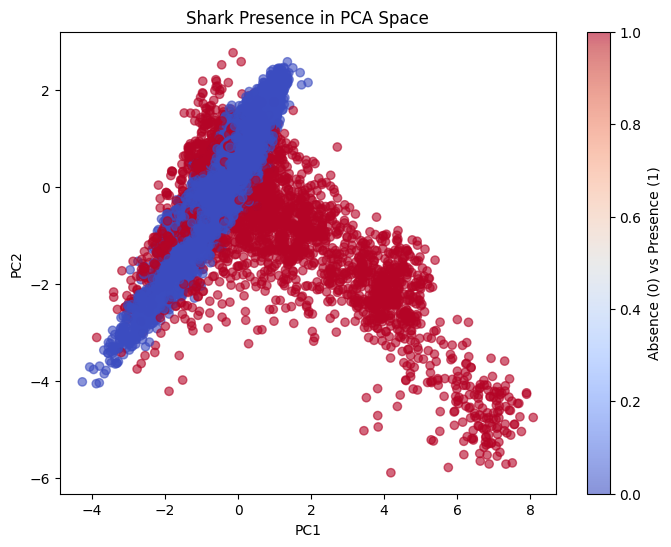

In [23]:
# K-Means Clustering: add shark presence as color

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=train_df_sup["presence"], cmap='coolwarm', alpha=0.6)
plt.title("Shark Presence in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Absence (0) vs Presence (1)")
plt.show()


shark presence dominates cluster 1 region and this just visually confirms what we saw using crosstab - shark detections appear under distinct conditions

In [24]:
# Sampled Hierarchical Clustering
## RAM issues using full dataset so needed to use a sampled version

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import cdist

# create sample of 5000 rows to avoid crashing RAM
sample_size = 5000
np.random.seed(42)

sample_idx = np.random.choice(X_unsup_train.shape[0], size=sample_size, replace=False)
X_sample = X_unsup_train[sample_idx]

print("Sampled hierarchical clustering on:", X_sample.shape)

# fit heirarchical clustering on sample
Z = linkage(X_sample, method="ward")

# assign clusters
sample_clusters = fcluster(Z, t=3, criterion="maxclust")

# compute sample centroids
centroids = np.vstack([
    X_sample[sample_clusters == k].mean(axis=0)
    for k in np.unique(sample_clusters)
])

# assign each full train/test set row to nearest centroid
train_df_unsup.loc[:, "hier_cluster"] = np.argmin(
    cdist(X_unsup_train, centroids), axis=1
) + 1

test_df_unsup.loc[:, "hier_cluster"] = np.argmin(
    cdist(X_unsup_test, centroids), axis=1
) + 1

print("Hierarchical cluster counts (sample-based):")
print(pd.Series(train_df_unsup["hier_cluster"]).value_counts())

Sampled hierarchical clustering on: (5000, 11)
Hierarchical cluster counts (sample-based):
hier_cluster
3    9782
2    4163
1     979
Name: count, dtype: int64


no built-in prediction method so test-set clusters are assigned using their nearest centroid mapping group. Originally, this kept crashing since it was using too much RAM trying to for the full cleaned dataset, which is large, so reduced to a sample size to remain computationally feasible while extracting clusters from the sample. Cluster results were consistent to k=3 K-means clusters

In [25]:
# Hierarchical Clustering: relationship to shark presence (crosstab)

hier_presence_ct = pd.crosstab(
    train_df_unsup["hier_cluster"],
    train_df_unsup["presence"],
    normalize="index"
)

hier_presence_ct

presence,0,1
hier_cluster,,
1,0.000000,1.000000
2,0.779486,0.220514
3,0.812513,0.187487


This step compares the clusters that were created w/o using shark pres. against actual shark pres/abs. Reflective of what we saw in K-means that one cluster had 100% shark presence showing a very specific environmental situation in which sharks were always detected. Strongly suggests that envir. conditions are linked to shark pres.

In [26]:
# Hierarchical Clustering: exploration of envir. ranges

# select cluster(s) with 100% presence
high_risk_clusters = hier_presence_ct[hier_presence_ct[1] == 1.0].index.tolist()

high_risk_clusters

# environmental features only (exclude labels & clusters)
env_features = [
    "wspd", "wdir", "pres", "atmp",
    "hour", "month", "year"
]

cluster_ranges = (
    train_df_unsup
    .loc[train_df_unsup["hier_cluster"].isin(high_risk_clusters)]
    [env_features]
    .agg(["min", "median", "max"])
    .T
)

cluster_ranges

,min,median,max
wspd,0.0,4.2,29.3
wdir,0.0,203.0,360.0
pres,975.4,1016.7,1025.2
atmp,18.5,27.1,29.4
hour,8.0,11.0,12.0
month,NaN,NaN,NaN
year,NaN,NaN,NaN


this table shows the cluster envir. conditions from when sharks were always present. median windspeed was calm/lower at 4.2 m/s as most typical - maybe prey appear more under stable ocean conditions, water clarity? wind direction doesn't appear to be a primary driver but may be a secondary. Shark presence appears to be concentrated in the late morning hours (8-12 with 11 as the median). Airtemp indicates warm-water preference - thermal conditions appear to be a key driving shark presence factor. Ocean pressure (pres) has a narrow range of 975.4-1025.2 with a median of 1016.7 hPa so the sharks seem to prefer stable, high-pressure systems (sea level/regular ocean pressure is 1013.25 hPa aka hectopascals and this is equivalent to 1 atmosphere, this surface pressure varies depending on weather systems)

Wind speed scale: http://gyre.umeoce.maine.edu/data/gomoos/buoy/php/variable_description.php?variable=wind_2_speed

In [27]:
# Hierarchical Clustering: compare high-risk vs other clusters
comparison = (
    train_df_unsup
    .assign(high_risk=lambda df: df["hier_cluster"].isin(high_risk_clusters))
    .groupby("high_risk")[env_features]
    .median()
)

comparison


,wspd,wdir,pres,atmp,hour,month,year
high_risk,,,,,,,
False,5.4,164.0,1018.0,25.0,11.0,7.0,2017.0
True,4.2,203.0,1016.7,27.1,11.0,NaN,NaN


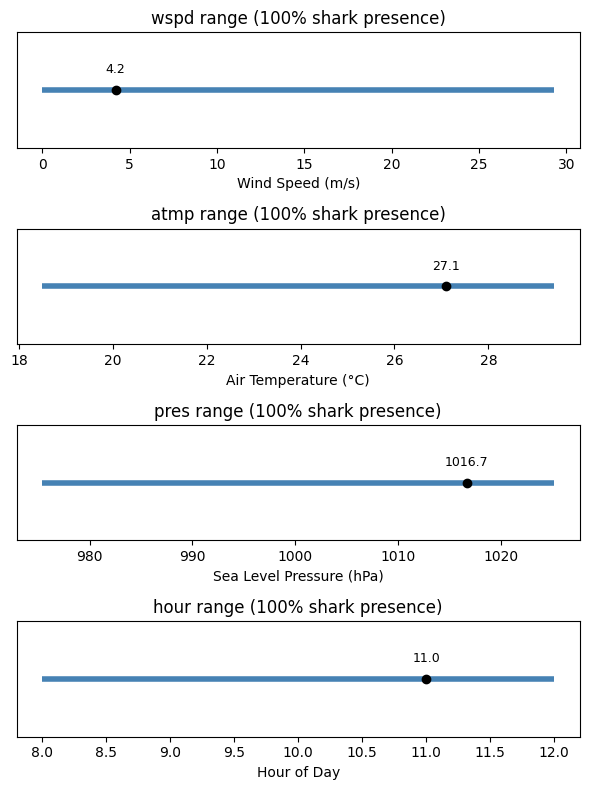

In [28]:
# Hierarchical Clustering: range plot
## min-max with median dot

import matplotlib.pyplot as plt

vars_to_plot = ["wspd", "atmp", "pres", "hour"]

# Labels with units
xlabels = {
    "wspd": "Wind Speed (m/s)",
    "atmp": "Air Temperature (°C)",
    "pres": "Sea Level Pressure (hPa)",
    "hour": "Hour of Day"
}

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(6, 8), sharex=False)

for ax, var in zip(axes, vars_to_plot):
    vmin = cluster_ranges.loc[var, "min"]
    vmed = cluster_ranges.loc[var, "median"]
    vmax = cluster_ranges.loc[var, "max"]

    # Range line
    ax.hlines(y=var, xmin=vmin, xmax=vmax, color="steelblue", linewidth=4)

    # Median point
    ax.plot(vmed, var, "o", color="black")

    # Median label ABOVE the dot
    ax.annotate(
        f"{vmed:.1f}",
        xy=(vmed, var),
        xytext=(0, 10),              # vertical offset in points
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

    ax.set_title(f"{var} range (100% shark presence)")
    ax.set_xlabel(xlabels[var])
    ax.set_yticks([])  # cleaner look

plt.tight_layout()
plt.show()


moderate wind speeds, warm air temperatures (consistent with seasonal expectations), stable sea-level pressure, late morning hours)

In [29]:
# Principal Component Analysis (PCA)

# fit PCA on training unsup features
pca = PCA(n_components=5)
pca.fit(X_unsup_train)

# transform train & test sets
train_pca = pca.transform(X_unsup_train)
test_pca  = pca.transform(X_unsup_test)

print("Explained variance ratios:", pca.explained_variance_ratio_)


Explained variance ratios: [0.17566898 0.14087952 0.11127208 0.1063982  0.09370515]


This tells us the total variation of environmental conditions. Seems like there
is no single factor dominating these variables. The 1st component explains about ~17% total variance while the 1st 5 components together account for ~63% of the variance. Suggests that envir. conditions are influenced by multiple factors simultaneously, rather than one overwhelming variable

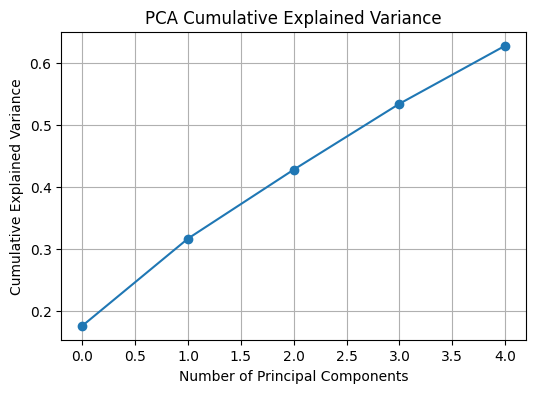

In [30]:
# PCA: Cumulative Variance plot

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()


gradual variance increase as additional components are added

In [31]:
# PCA: PCA Loadings
## what drives PC1 & PC2

loadings = pd.DataFrame(
    pca.components_.T,
    index=unsup_train.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings.sort_values("PC1", key=abs, ascending=False).head(10)


,PC1,PC2,PC3,PC4,PC5
lat,0.553061,-0.395997,0.100602,0.020399,-0.103525
lon,0.534122,-0.436531,0.038029,0.058057,-0.093650
atmp,0.471455,0.476542,-0.070321,0.009762,0.031409
wspd,-0.235262,-0.167492,-0.184365,-0.414691,-0.474752
pres,-0.224868,-0.076784,0.311225,0.652813,-0.231899
month,0.222434,0.384136,-0.400102,-0.128769,-0.040554
wdir,-0.154798,-0.414074,-0.032828,-0.413517,0.430426
year,0.072666,0.171616,0.584064,-0.321317,-0.098150
minute,-0.037324,-0.198515,-0.562383,0.314764,0.129228
hour,0.022771,0.060551,0.180965,0.084271,0.678571


aligns with earlier finding that no single variable explains shark presence

In [32]:
# Gaussian Mixture Model (GMM)
## after the issues with trying Hier. model on full dataset, wanted to try this model for large dataset

from sklearn.mixture import GaussianMixture

# fit GMM on training unsupervised features
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)
gmm.fit(X_unsup_train)

# predict cluster memberships
train_df_unsup.loc[:, "gmm_cluster"] = gmm.predict(X_unsup_train)
test_df_unsup.loc[:, "gmm_cluster"]  = gmm.predict(X_unsup_test)

# predict soft cluster probabilities
gmm_probs = gmm.predict_proba(X_unsup_train)

train_df_unsup.loc[:, "gmm_p1"] = gmm_probs[:, 0]
train_df_unsup.loc[:, "gmm_p2"] = gmm_probs[:, 1]
train_df_unsup.loc[:, "gmm_p3"] = gmm_probs[:, 2]

print("GMM cluster counts:")
print(train_df_unsup["gmm_cluster"].value_counts())

GMM cluster counts:
gmm_cluster
2    11187
1     3720
0       17
Name: count, dtype: int64


GMM can do elliptical clusters (K-means only allows for spherical shapes). so provides a more flexible unsup representation of environmental factors. The largest cluster is likely the typical environmental conditions (cluster 0) while cluster 1 is moderately sized so may show a secondary trend for certain environmental conditions. Cluster 2 which is the smallest cluster is likely linked to rare/unusual weather patterns

In [33]:
# GMM: cluster vs presence crosstab

# GMM clusters vs shark presence
gmm_presence_ct = pd.crosstab(
    train_df_unsup["gmm_cluster"],
    train_df_unsup["presence"],
    normalize="index"
)

gmm_presence_ct


presence,0,1
gmm_cluster,,
0,0.352941,0.647059
1,0.000000,1.000000
2,1.000000,0.000000


Cluster 1 is perfectly associated with shark presence while clusters 0 & 2 are overwhelmingly showing shark absence. Lines up with what we've seen in the other unsupervised models - certain environmental conditions organically align with biological behaviors at least as they relate to shark presence

# Supervised Models

In [34]:
# Baseline Logistic Regression (LR) model - using default L2 regularization (no tuning)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Build & fit model
log_baseline = LogisticRegression(
    penalty="l2",     # standard LR
    solver="lbfgs",
    max_iter=2000,
)

log_baseline.fit(X_train_processed, y_train)

# Predictions
train_pred = log_baseline.predict(X_train_processed)
test_pred  = log_baseline.predict(X_test_processed)
test_proba = log_baseline.predict_proba(X_test_processed)[:,1]

# Evaluation
print("\n=== BASELINE LOGISTIC REGRESSION RESULTS ===")
print("\nClassification Report:")
print(classification_report(y_test, test_pred))

roc = roc_auc_score(y_test, test_proba)
print("ROC-AUC:", roc)


=== BASELINE LOGISTIC REGRESSION RESULTS ===

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4353
           1       1.00      0.84      0.92      1451

    accuracy                           0.96      5804
   macro avg       0.98      0.92      0.95      5804
weighted avg       0.96      0.96      0.96      5804

ROC-AUC: 0.94194407621161


performed very well and almost never falsely predicts a shark when none are present. this model is good with the binary nature/classification and provides clear benchmark. Accuracy of 96%, recall for pres. is slightly low (0.84) so some missed detections likely given class imbalance. ROC-AUC of ~0.94 suggesting strong class separation

In [35]:
# Penalized Logistic Regression (LR) model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

penalties = {
    "L1": {"penalty": "l1", "solver": "liblinear"},
    "L2": {"penalty": "l2", "solver": "lbfgs"},
    "ElasticNet": {"penalty": "elasticnet", "solver": "saga", "l1_ratio": 0.5}
}

results = {}

print("\n=== PENALIZED LOGISTIC REGRESSION MODELS ===\n")

for name, params in penalties.items():

    model = LogisticRegression(
        max_iter=3000,
        **params
    )

    model.fit(X_train_processed, y_train)

    # Predictions
    test_pred = model.predict(X_test_processed)
    test_proba = model.predict_proba(X_test_processed)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, test_proba)
    results[name] = auc

    print(f"\n--- {name} Logistic Regression ---")
    print(classification_report(y_test, test_pred))
    print(f"{name} ROC-AUC: {auc:.4f}")

print("\nSummary of ROC-AUC Scores:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")



=== PENALIZED LOGISTIC REGRESSION MODELS ===


--- L1 Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      4353
           1       1.00      0.86      0.92      1451

    accuracy                           0.96      5804
   macro avg       0.98      0.93      0.95      5804
weighted avg       0.97      0.96      0.96      5804

L1 ROC-AUC: 0.9422

--- L2 Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4353
           1       1.00      0.84      0.92      1451

    accuracy                           0.96      5804
   macro avg       0.98      0.92      0.95      5804
weighted avg       0.96      0.96      0.96      5804

L2 ROC-AUC: 0.9419

--- ElasticNet Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      4353
           1       1.00      0.85      0.92     

ROC-AUC scores were pretty stable (~0.94). Elastic Net balances both L1 (lasso) and L2 (ridge). Negligible diff. btwn baseline LR & penalized LR but L1 & Elastic Net seem to have slightly improved Recall. Data seems to be largely linear given stability

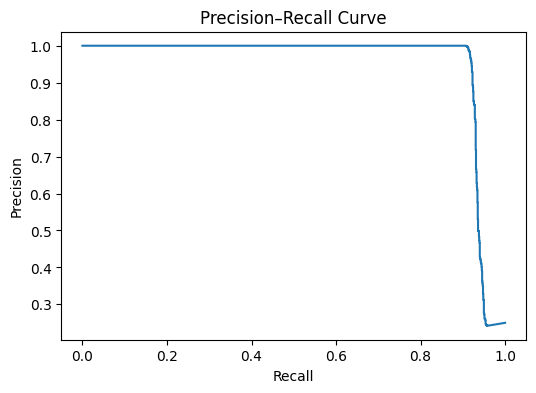

In [36]:
# Precision-Recall (PR) Curve

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, test_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


The PR curve is too good - almost 1.0 precision entire recall range then sharp vertical drop at recall about 1.0

model almost never predicts shark pres. incorrectly and when it does predict pres., it's almost always correct. model is cautious and may miss some real shark events. favors precision over recall

*note: future research work to involve selecting decision thresholds based on acceptable false-pos. risk

In [37]:
# Cross validation
## need to use TimeSeriesSplit for CV so it is forward-chaining (5 folds) to prevent time leakage

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

cv_auc_scores = []

fold = 1
for train_index, val_index in tscv.split(X_train_processed):
    X_tr, X_val = X_train_processed[train_index], X_train_processed[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    # fit a simple LR model
    lr_cv = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000
    )
    lr_cv.fit(X_tr, y_tr)

    # predict and calculate ROC-AUC
    val_pred = lr_cv.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, val_pred)
    cv_auc_scores.append(auc)

    print(f"Fold {fold} AUC: {auc:.4f}")
    fold += 1

print("\nMean CV AUC:", np.mean(cv_auc_scores))
print("Std Dev CV AUC:", np.std(cv_auc_scores))


Fold 1 AUC: 1.0000
Fold 2 AUC: 0.9979
Fold 3 AUC: 0.1622
Fold 4 AUC: 0.9138
Fold 5 AUC: 0.9964

Mean CV AUC: 0.8140590564376898
Std Dev CV AUC: 0.3275777515277733


fold 3 is worse than random guessing. volatility across folds may be linked to real world forecasting difficulty and less so model failure. This model is sensitive to temporal distribution of shark detections so instability of results reflects that


In [38]:
# Check Independence (Durbin–Watson)

from statsmodels.stats.stattools import durbin_watson

# compute residuals
residuals = y_test - test_proba
dw = durbin_watson(residuals)

print("Durbin-Watson Statistic:", dw)


Durbin-Watson Statistic: 1.8539411108008668


DW ≈ 2 → no autocorrelation

DW < 1 → strong positive autocorrelation

so this is an acceptable result thus residual indep. assumption is cleared for LR since indicates no meaningful autocorr. in residuals

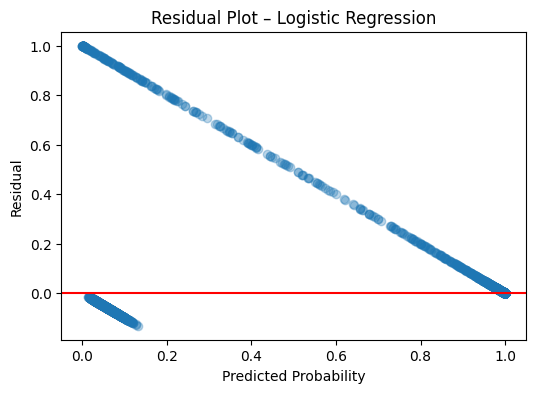

In [39]:
# Residual Plots (Logistic Equivalent)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(test_proba, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted Probability")
plt.ylabel("Residual")
plt.title("Residual Plot – Logistic Regression")
plt.show()


helps in identifying misspecification. Residual behavior is consistent with well-specified logistic model. no clear signs of structural bias

In [40]:
# Gradient Boosting Classifier model

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Build model
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Fit
gb_clf.fit(X_train_processed, y_train)

# Predict
gb_pred = gb_clf.predict(X_test_processed)
gb_proba = gb_clf.predict_proba(X_test_processed)[:,1]

print("\n=== GRADIENT BOOSTING RESULTS ===")
print(classification_report(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_proba))



=== GRADIENT BOOSTING RESULTS ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4353
           1       1.00      1.00      1.00      1451

    accuracy                           1.00      5804
   macro avg       1.00      1.00      1.00      5804
weighted avg       1.00      1.00      1.00      5804

ROC-AUC: 1.0


GB choosen since it's able to capture nonlinear relationships in contrast to LR models. It ended up with perfect performance which unusual for real world data. May suggest data leakage, severe overfitting, or a dominant predictor so need to investigate reliability

In [41]:
# GB: feature importance - looking for top 10 predictors
## shows how much each variable contributes to reducing error across all trees

importances = gb_clf.feature_importances_

# match to column names from preprocessor
feature_names = supervised_preprocessor.get_feature_names_out()

# create sorted table
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)


,feature,importance
0,num__lon,1.000000e+00
1,num__lat,2.683887e-14
4,num__wdir,1.096057e-14
6,num__pres,1.336317e-15
5,num__wspd,2.820137e-16
8,num__year,6.539984e-17
2,num__hour,1.498106e-17
3,num__minute,0.000000e+00
9,num__month,0.000000e+00
10,num__day,0.000000e+00


location (longitude) dominates so seems like model is relaying on that for shark presence, may not do well in new locations. So seems like this model may solely be using location to predict shark presence so learning where they are, not why they are there. This would mean this model would be unable to generalize in other new locations. Overfitting spatial/over-reliant on longitude

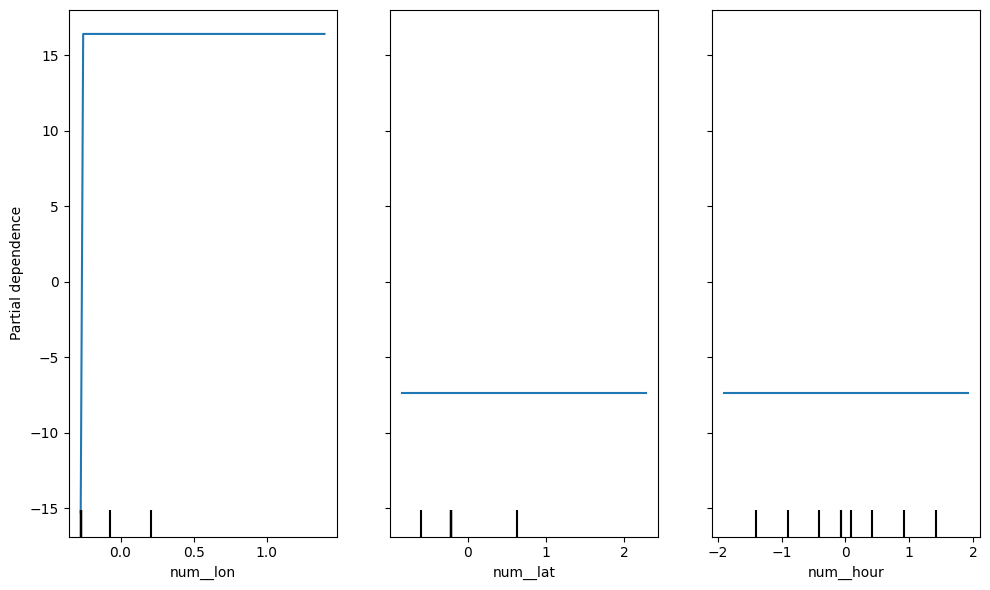

In [42]:
# GB: Partial Dependence Plots (PDP)
## shows how predicted probability changes as oen feature varies, holding all others constant

from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10,6))
PartialDependenceDisplay.from_estimator(
    gb_clf,
    X_train_processed,
    [0, 1, 2],        # <-- replace with indices of your meaningful features
    feature_names=feature_names,
    ax=ax
)
plt.tight_layout()
plt.show()


show that the model is not learning relationships. predictions are changing sharply based solely on location. So spatially focused model instead of the environmental focus that we were looking for

In [43]:
# GB: overfitting check - train vs test

from sklearn.metrics import accuracy_score, roc_auc_score

train_pred_gb = gb_clf.predict(X_train_processed)
test_pred_gb  = gb_clf.predict(X_test_processed)

train_auc = roc_auc_score(y_train, gb_clf.predict_proba(X_train_processed)[:,1])
test_auc  = roc_auc_score(y_test, gb_clf.predict_proba(X_test_processed)[:,1])

print("Train Accuracy:", accuracy_score(y_train, train_pred_gb))
print("Test Accuracy:", accuracy_score(y_test, test_pred_gb))
print("Train AUC:", train_auc)
print("Test AUC:", test_auc)


Train Accuracy: 1.0
Test Accuracy: 1.0
Train AUC: 1.0
Test AUC: 1.0


model perfectly fits both so suggests overfitting - model memorized patterns tied to geography

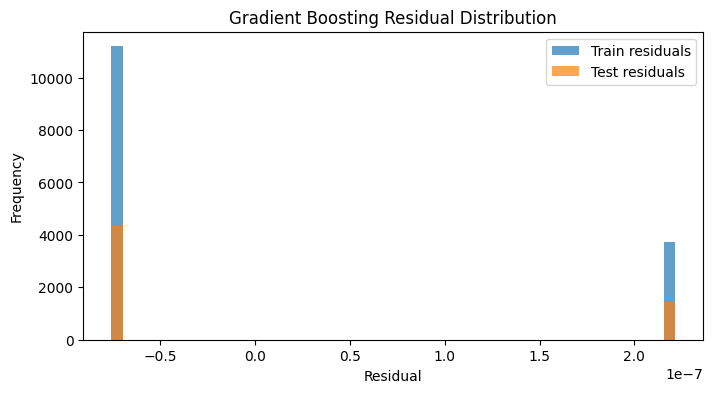

In [44]:
# GB: Residual Diagnostics for Classification

# calc pseudo-residuals
# Compute predicted probabilities
train_proba = gb_clf.predict_proba(X_train_processed)[:,1]
test_proba  = gb_clf.predict_proba(X_test_processed)[:,1]

# Residuals (observed - predicted)
train_resid = y_train - train_proba
test_resid  = y_test - test_proba

# plot residual distribution

plt.figure(figsize=(8,4))
plt.hist(train_resid, bins=50, alpha=0.7, label="Train residuals")
plt.hist(test_resid, bins=50, alpha=0.7, label="Test residuals")
plt.legend()
plt.title("Gradient Boosting Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


extremely concentrated near 0. shows overconfidence and overfitting

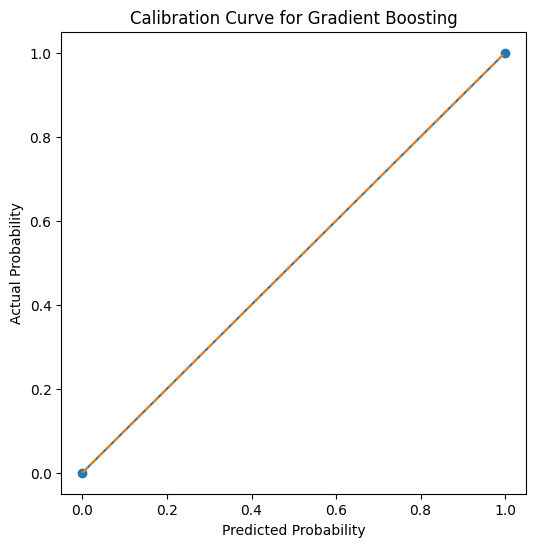

In [45]:
# GB: calibration curve - for probability reliability check

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.title("Calibration Curve for Gradient Boosting")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.show()


Since this is almost perfectly diagonal, however, this "perfect calibration" result shown here is more a symptom of the model's overfitting, not actual probabilistic reliability for the model

In [46]:
# GB Hyperparameter Tuning: Grid Search
## took about 9 minutes to complete running

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=5) # ensures forward-chaining cv to prevent time leakage

# base model
gb_base = GradientBoostingClassifier(random_state=42)

# hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],  # number of trees
    "learning_rate": [0.01, 0.05, 0.1],  # contribution of each tree
    "max_depth": [2, 3],                # depth of each tree
    "min_samples_leaf": [20, 50],       # min. samples per leaf
    "subsample": [0.7, 0.9]             # fraction of data per tree
}

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_processed, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 200, 'subsample': 0.9}
Best CV ROC-AUC: 0.8885828654735249


systematically tuning key GB hyperparameters to find best parameters

In [47]:
# GB Hyperparameter Tuning: tuned model evaluation

best_gb = grid_search.best_estimator_

# predictions
gb_tuned_pred = best_gb.predict(X_test_processed)
gb_tuned_proba = best_gb.predict_proba(X_test_processed)[:, 1]

print("\n=== TUNED GRADIENT BOOSTING RESULTS ===")
print(classification_report(y_test, gb_tuned_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, gb_tuned_proba))



=== TUNED GRADIENT BOOSTING RESULTS ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4353
           1       1.00      1.00      1.00      1451

    accuracy                           1.00      5804
   macro avg       1.00      1.00      1.00      5804
weighted avg       1.00      1.00      1.00      5804

Test ROC-AUC: 1.0


evaluated on test set performance, still perfect 1's across the board. Still likely experiencing data leakage through spatial/location

In [48]:
# GB Hyperparameter Tuning: Overfitting comparison check

train_auc_tuned = roc_auc_score(
    y_train, best_gb.predict_proba(X_train_processed)[:,1]
)
test_auc_tuned = roc_auc_score(
    y_test, best_gb.predict_proba(X_test_processed)[:,1]
)

print("Tuned Train AUC:", train_auc_tuned)
print("Tuned Test AUC:", test_auc_tuned)


Tuned Train AUC: 1.0
Tuned Test AUC: 1.0


longitude and latitude still appear to dominate this model and presence vs absence are seemingly almost perfectly separable by location. This means that this model could likely not be used in a different geographic region successfully

In [49]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_processed, y_train)

rf_pred = rf_baseline.predict(X_test_processed)
rf_proba = rf_baseline.predict_proba(X_test_processed)[:, 1]

print("\n=== RANDOM FOREST BASELINE RESULTS ===")
print(classification_report(y_test, rf_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, rf_proba))



=== RANDOM FOREST BASELINE RESULTS ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4353
           1       1.00      1.00      1.00      1451

    accuracy                           1.00      5804
   macro avg       1.00      1.00      1.00      5804
weighted avg       1.00      1.00      1.00      5804

Test ROC-AUC: 1.0


In [50]:
# Random Forest: Overfitting Check

train_auc_rf = roc_auc_score(
    y_train, rf_baseline.predict_proba(X_train_processed)[:,1]
)
test_auc_rf = roc_auc_score(
    y_test, rf_baseline.predict_proba(X_test_processed)[:,1]
)

print("RF Train AUC:", train_auc_rf)
print("RF Test AUC:", test_auc_rf)


RF Train AUC: 1.0
RF Test AUC: 1.0


seems to be performing identically to the GB model

In [51]:
# Random Forest: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 10, 20],
    "max_features": ["sqrt", 0.5],
}

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_processed, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best CV ROC-AUC:", grid_rf.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV ROC-AUC: 1.0


In [52]:
# Random Forest: Evaluate Tuned model

rf_best = grid_rf.best_estimator_

rf_pred = rf_best.predict(X_test_processed)
rf_proba = rf_best.predict_proba(X_test_processed)[:,1]

print("\n=== TUNED RANDOM FOREST RESULTS ===")
print(classification_report(y_test, rf_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, rf_proba))

print("Train AUC:", roc_auc_score(
    y_train, rf_best.predict_proba(X_train_processed)[:,1]
))
print("Test AUC:", roc_auc_score(
    y_test, rf_best.predict_proba(X_test_processed)[:,1]
))



=== TUNED RANDOM FOREST RESULTS ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4353
           1       1.00      1.00      1.00      1451

    accuracy                           1.00      5804
   macro avg       1.00      1.00      1.00      5804
weighted avg       1.00      1.00      1.00      5804

Test ROC-AUC: 1.0
Train AUC: 1.0
Test AUC: 1.0


Same as the tuned GB model as well in that it's too well suited to this dataset and uses spatial data to determine patterns so this also wouldn't be able to be used at different locations

In [53]:
# Intentional removal of spatial feature (remove lat/lon)

# id non-spatial features
non_spatial_features = [
    f for f in supervised_preprocessor.get_feature_names_out()
    if "lon" not in f and "lat" not in f
]

# extract indices for non-spatial features
feature_idx = [
    i for i, f in enumerate(supervised_preprocessor.get_feature_names_out())
    if f in non_spatial_features
]

# subset processed matrices
X_train_nospatial = X_train_processed[:, feature_idx]
X_test_nospatial  = X_test_processed[:, feature_idx]

print("Original feature count:", X_train_processed.shape[1])
print("Non-spatial feature count:", X_train_nospatial.shape[1])


Original feature count: 11
Non-spatial feature count: 9


Removed latitude and longitude to prevent spatial memorization so the model needs to focus on environmental predictors/features. Can environmental features alone explain shark presence?

In [54]:
# Logistic Regression fit using spatially-restricted

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# fit LR w/o spatial features
log_nospatial = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=2000
)

log_nospatial.fit(X_train_nospatial, y_train)

# predictions
test_pred_ns  = log_nospatial.predict(X_test_nospatial)
test_proba_ns = log_nospatial.predict_proba(X_test_nospatial)[:, 1]

# evaluation
print("\n=== SPATIALLY-RESTRICTED LOGISTIC REGRESSION RESULTS ===")
print(classification_report(y_test, test_pred_ns))
print("ROC-AUC:", roc_auc_score(y_test, test_proba_ns))



=== SPATIALLY-RESTRICTED LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      4353
           1       0.00      0.00      0.00      1451

    accuracy                           0.75      5804
   macro avg       0.38      0.50      0.43      5804
weighted avg       0.56      0.75      0.64      5804

ROC-AUC: 0.6391034297029403


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Using LR to test its generalizability beyond known geographic locations to see if there's any performance drop based on contribution of environmental variables w/o spatial features. The model only predicts absence (0) and never predicts presence (1) so it seems like this LR model is defaulting to the majority class (absence). Thus, without spatial features the model isn't able to learn a decision boundary for the classes

In [55]:
# LR time-Aware Cross-Validation
## forward-chaining cv to avoid temporal leakage

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
auc_scores = []

for train_idx, val_idx in tscv.split(X_train_nospatial):
    X_tr, X_val = X_train_nospatial[train_idx], X_train_nospatial[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LogisticRegression(max_iter=2000)
    model.fit(X_tr, y_tr)

    val_proba = model.predict_proba(X_val)[:,1]
    auc_scores.append(roc_auc_score(y_val, val_proba))

print("Mean CV AUC:", np.mean(auc_scores))
print("Std Dev CV AUC:", np.std(auc_scores))


Mean CV AUC: 0.4028209004839656
Std Dev CV AUC: 0.48150636311571704


Any AUC scores near 0.5 are considered to be akin to random guessing, which suggests this model is unstable, worse than random, and entirely lacks reliable discrimination abilities for the classes. So environmental factors alone seemingly cannot reliabily separate presence vs absence